In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [3]:
results_folder = "../results/TimeSeries/2D"
create_folder(results_folder)

## 1 COLOR - MULTIPLES $p_0$

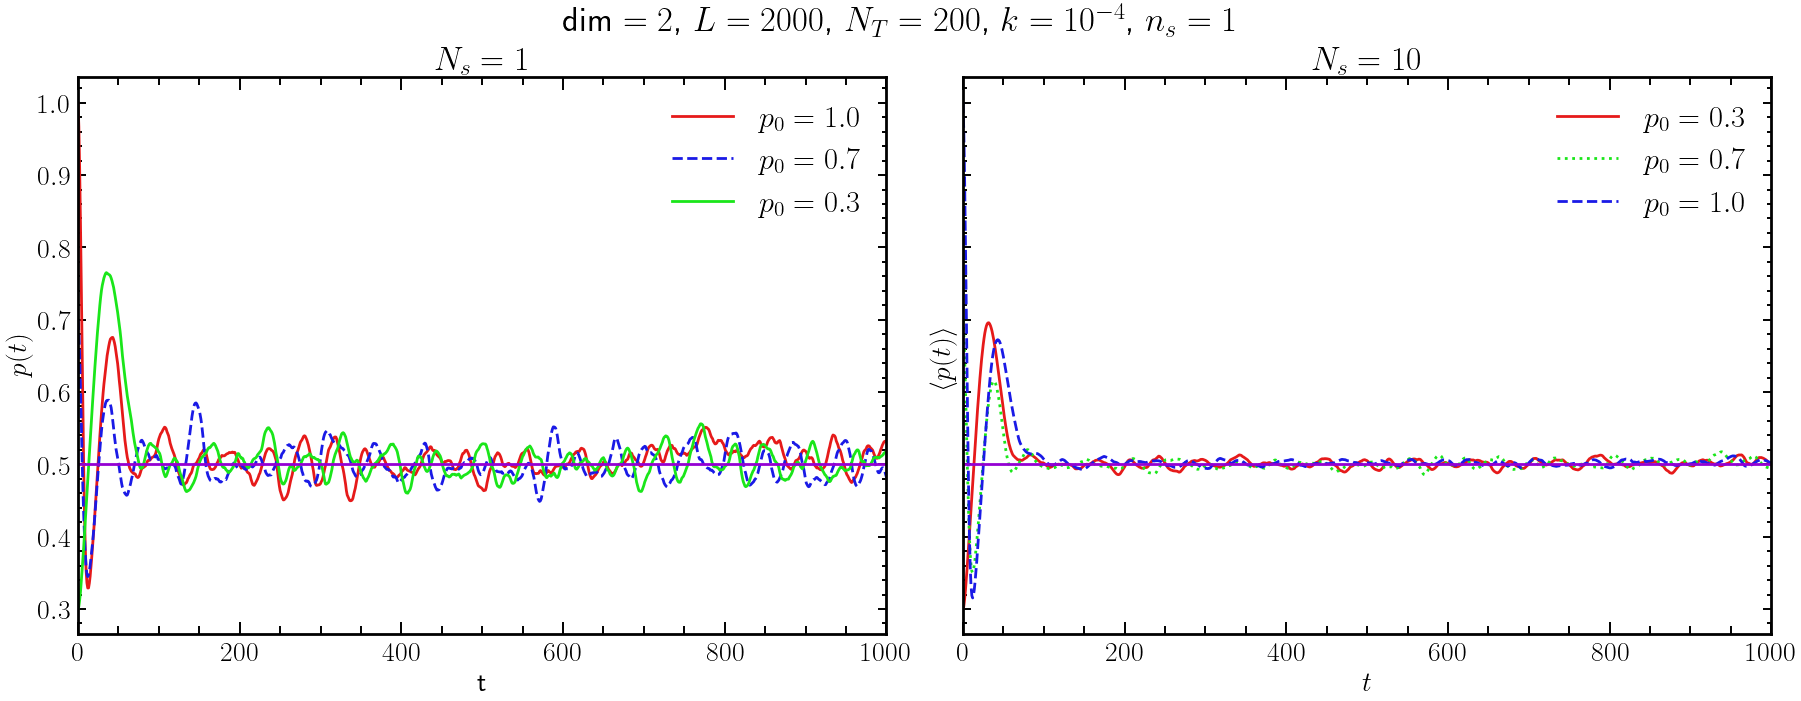

In [9]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================
L = 2000
dim = 2
nc = 1
rho = 1 / nc
k = 1.0e-04
NT = 200
p0 = 1.0
seed = 1
z_level = 0

path_dir_raw = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
fn1 = path_dir_raw + "complex_seed_22744820_ts_20260326T151418_P0_0.10_p0_1.00.json"
fn2 = path_dir_raw + "complex_seed_431596886_ts_20260326T151800_P0_0.10_p0_0.70.json"
fn3 = path_dir_raw + "complex_seed_488465044_ts_20260326T151730_P0_0.10_p0_0.30.json"

dicT1 = read_experiment_json(fn1)
dicT2 = read_experiment_json(fn2)
dicT3 = read_experiment_json(fn3)

order_raw = 1
pc = 0.5
lw = 2.0

colors_used = [
    (0.9, 0.1, 0.1),
    (0.1, 0.1, 0.9),
    (0.1, 0.9, 0.1),
    (1.0, 0.5, 0.0),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

pt1 = dicT1['results'][f'order_percolation {order_raw}']['data']['pt']
t1  = dicT1['results'][f'order_percolation {order_raw}']['data']['time']

pt2 = dicT2['results'][f'order_percolation {order_raw}']['data']['pt']
t2  = dicT2['results'][f'order_percolation {order_raw}']['data']['time']

pt3 = dicT3['results'][f'order_percolation {order_raw}']['data']['pt']
t3  = dicT3['results'][f'order_percolation {order_raw}']['data']['time']


# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
bundle_path = path_dir_pub + "properties_mean_bundle.json"
bundle = load_properties_bundle(bundle_path)

order_mean = 0


# =========
# FIGURA
# =========
fig, ax = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# Painel esquerdo
ax[0].plot(t1, pt1, ls='-',  lw=lw, color=colors_used[0], label=r"$p_0 = 1.0$")
ax[0].plot(t2, pt2, ls='--', lw=lw, color=colors_used[1], label=r"$p_0 = 0.7$")
ax[0].plot(t3, pt3, ls='-',  lw=lw, color=colors_used[2], label=r"$p_0 = 0.3$")

ax[0].axhline(y=pc, color="darkviolet", lw=lw)
ax[0].set_xlim(0, 1000)
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$p(t)$")
ax[0].set_title(r"$N_s = 1$")
ax[0].legend(fontsize=22)

# Painel direito
for p0_val in sorted(bundle.keys()):
    data = bundle[p0_val]["orders"][order_mean]
    time = data["time"]
    pt_mean = data["pt_mean"]

    ax[1].plot(time, pt_mean, lw=lw, label=fr"$p_0 = {p0_val:.1f}$")

ax[1].axhline(y=pc, color="darkviolet", lw=lw)
ax[1].set_xlim(0, 1000)
ax[1].set_xlabel("$t$")
ax[1].set_ylabel(r"$\langle p(t)\rangle$")
ax[1].set_title(r"$N_s = 10$")
ax[1].legend(fontsize=22)
for a in ax:
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, labelleft=False, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, labelleft=False, length=3)

ax[0].tick_params(axis='y', which='major', labelleft=True)

fig.suptitle(r"dim $= 2$, $L = 2000$, $N_T = 200$, $k=10^{{{-4}}}$, $n_s = 1$", fontsize=25)
plt.savefig(results_folder + "/Multiple_p0.pdf")
plt.show()